# Импорт библиотек

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, log_loss

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


df = pd.read_csv("train.csv")

# Создание новых признаков

In [37]:
def create_features(data):
    d = data.copy()
    
    # Отношение годового дохода к сумме займа
    d["income_to_loan_ratio"] = d["annual_income"] / (d["loan_amount"] + 1)
    
    # Абсолютный объем текущего долга
    d["debt_volume"] = d["annual_income"] * (d["debt_to_income_ratio"] / 100.0)
    
    # Отношение кредитного рейтинга к процентной ставке
    d["score_to_rate"] = d["credit_score"] / (d["interest_rate"] + 0.1)
    
    return d

df = create_features(df)

target_col = "loan_paid_back"
drop_cols = ["id", target_col]

X = df.drop(columns=drop_cols)
y = df[target_col]

cat_features = [
    "gender", "marital_status", "education_level", 
    "employment_status", "loan_purpose", "grade_subgrade"
]

# Разделяем выборку на test and train

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (475195, 14)
Размер тестовой выборки: (118799, 14)


# Обучаем CatBoost

In [39]:
# Сначала считаем коэффициент дисбаланса
# ratio = количество_положительных / количество_отрицательных
ratio = len(y_train[y_train == 1]) / len(y_train[y_train == 0])

model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.02,
    depth=7,
    l2_leaf_reg=5,
    eval_metric='AUC',
    bootstrap_type='Bernoulli',
    subsample=0.8,
    scale_pos_weight=ratio,
    random_seed=42,
    verbose=200,
    early_stopping_rounds=200
)

model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True,
    plot=False  
)


test_preds = model.predict_proba(X_test)[:, 1]

0:	test: 0.8981823	best: 0.8981823 (0)	total: 198ms	remaining: 6m 35s
200:	test: 0.9138927	best: 0.9138927 (200)	total: 49.1s	remaining: 7m 19s
400:	test: 0.9153972	best: 0.9153972 (400)	total: 1m 40s	remaining: 6m 41s
600:	test: 0.9161649	best: 0.9161649 (600)	total: 2m 29s	remaining: 5m 48s
800:	test: 0.9172834	best: 0.9172834 (800)	total: 3m 26s	remaining: 5m 9s
1000:	test: 0.9180929	best: 0.9180929 (1000)	total: 4m 21s	remaining: 4m 21s
1200:	test: 0.9186757	best: 0.9186757 (1200)	total: 5m 20s	remaining: 3m 32s
1400:	test: 0.9191058	best: 0.9191069 (1399)	total: 6m 15s	remaining: 2m 40s
1600:	test: 0.9195409	best: 0.9195410 (1599)	total: 7m 9s	remaining: 1m 47s
1800:	test: 0.9198670	best: 0.9198670 (1800)	total: 8m 2s	remaining: 53.3s
1999:	test: 0.9201613	best: 0.9201613 (1999)	total: 8m 56s	remaining: 0us

bestTest = 0.9201612778
bestIteration = 1999



Отчёт по метрикам

              precision    recall  f1-score   support

         0.0       0.89      0.61      0.72     23900
         1.0       0.91      0.98      0.94     94899

    accuracy                           0.91    118799
   macro avg       0.90      0.79      0.83    118799
weighted avg       0.90      0.91      0.90    118799

Accuracy: 0.90568
Log-Loss: 0.24672

Итоговый ROC AUC на отложенной выборке: 0.92045


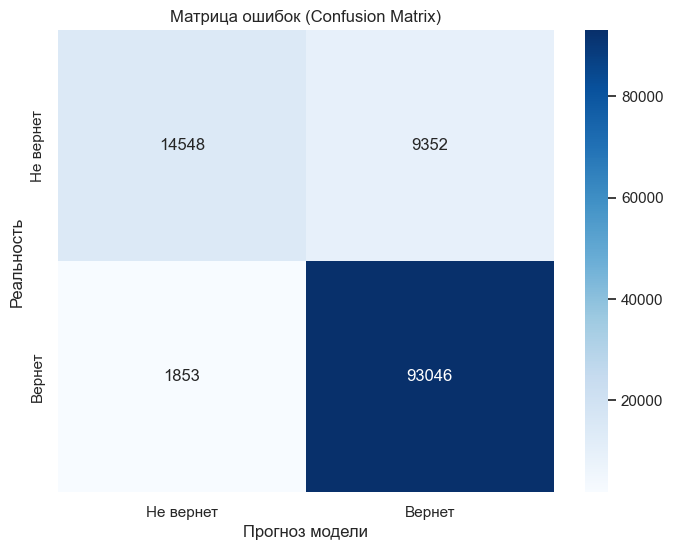

In [40]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
loss = log_loss(y_test, y_prob)

print(f"Accuracy: {acc:.5f}")
print(f"Log-Loss: {loss:.5f}")
print(f"\nИтоговый ROC AUC на отложенной выборке: {final_auc:.5f}")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Не вернет', 'Вернет'], 
            yticklabels=['Не вернет', 'Вернет'])
plt.ylabel('Реальность')
plt.xlabel('Прогноз модели')
plt.title('Матрица ошибок (Confusion Matrix)')
plt.show()


Text(0.5, 1.0, 'Матрица корреляций признаков')

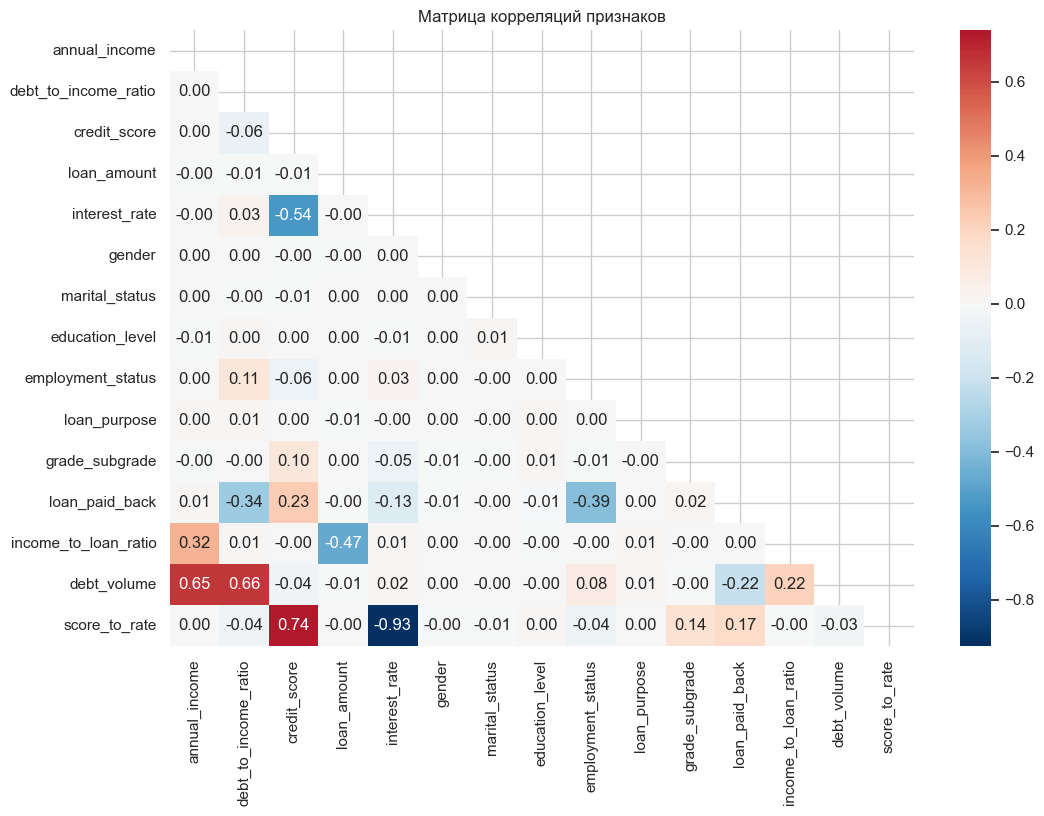

In [41]:
plt.figure(figsize=(12, 8))
df_corr = df.drop(columns=['id']).copy()

for col in cat_features:
    df_corr[col] = pd.factorize(df_corr[col])[0]

mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title("Матрица корреляций признаков")

Значимость признаков

Text(0.5, 0, 'Значимость признака')

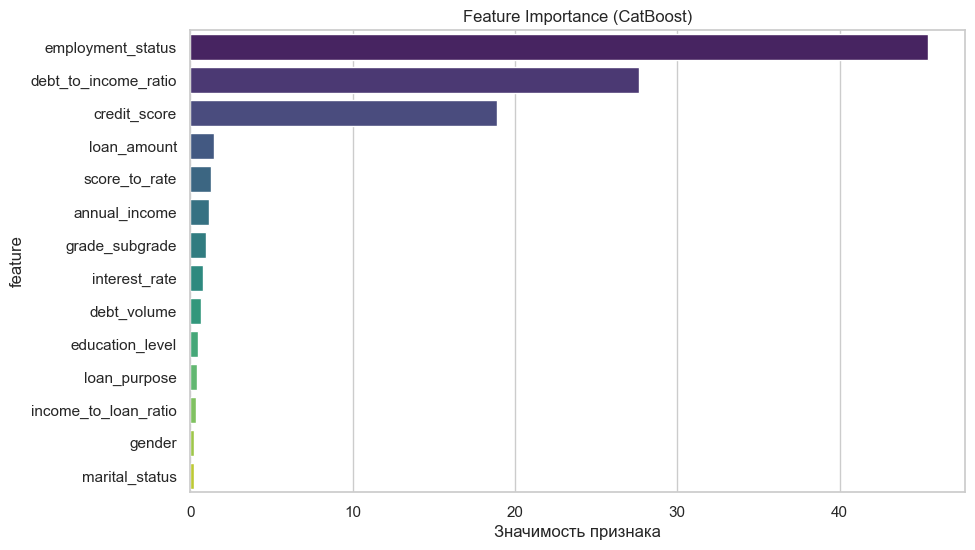

In [42]:
fi_df = pd.DataFrame({
    'feature': X_train.columns, 
    'importance': model.get_feature_importance()
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=fi_df, palette='viridis')
plt.title("Feature Importance (CatBoost)")
plt.xlabel("Значимость признака")

# Тестовые клиенты

In [43]:
def prepare_new_client(client_dict):
    df_client = pd.DataFrame([client_dict])
    
    df_client["income_to_loan_ratio"] = df_client["annual_income"] / (df_client["loan_amount"] + 1)
    df_client["debt_volume"] = df_client["annual_income"] * (df_client["debt_to_income_ratio"] / 100.0)
    df_client["score_to_rate"] = df_client["credit_score"] / (df_client["interest_rate"] + 0.1)
    
    return df_client

client_good = {
    'annual_income': 120000,
    'debt_to_income_ratio': 10.0,
    'credit_score': 780,
    'loan_amount': 20000,
    'interest_rate': 7.5,
    'gender': 'Male',
    'marital_status': 'Married',
    'education_level': 'Master',
    'employment_status': 'Employed',
    'loan_purpose': 'Home Improvement',
    'grade_subgrade': 'A1'
}

client_risky = {
    'annual_income': 35000,
    'debt_to_income_ratio': 40.0,
    'credit_score': 590,
    'loan_amount': 45000,
    'interest_rate': 24.0,
    'gender': 'Female',
    'marital_status': 'Single',
    'education_level': 'High School',
    'employment_status': 'Unemployed',
    'loan_purpose': 'Education',
    'grade_subgrade': 'E3'
}

for name, data in [("Надежный клиент", client_good), ("Рискованный клиент", client_risky)]:
    processed_data = prepare_new_client(data)
    
    prob = model.predict_proba(processed_data)[0][1]
    verdict = model.predict(processed_data)[0]
    
    print(f"=== {name} ===")
    print(f"Рассчитанный доход к займу: {processed_data['income_to_loan_ratio'].values[0]:.2f}")
    print(f"Объем текущего долга: {processed_data['debt_volume'].values[0]:.2f}")
    print(f"Вероятность возврата: {prob:.2%}")
    print(f"Решение: {'ОДОБРЕНО' if verdict == 1 else 'ОТКАЗ'}\n")

=== Надежный клиент ===
Рассчитанный доход к займу: 6.00
Объем текущего долга: 12000.00
Вероятность возврата: 78.96%
Решение: ОДОБРЕНО

=== Рискованный клиент ===
Рассчитанный доход к займу: 0.78
Объем текущего долга: 14000.00
Вероятность возврата: 0.04%
Решение: ОТКАЗ

